In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import netcdf
import netCDF4 as nc
# fname 为 你下载的字体库路径，注意 SourceHanSansSC-Bold.otf 字体的路径
import matplotlib
zhfont1 = matplotlib.font_manager.FontProperties(fname=r"/home/zhangzhibo/font/SourceHanSansSC-Bold.otf") 


In [84]:
file_path_base = r'/home/zhangzhibo/serghei/serghei-20240910-RTM/tests/t6-40-200/'

subsurface_file_path = file_path_base + r'out-8/output_subsurface.nc'
subsurface_dataset =  nc.Dataset(subsurface_file_path, 'r') # 'r' 表示只读模式
wc_out = subsurface_dataset.variables['wc'][:]
h_out = subsurface_dataset.variables['hd'][:]
qx_out = subsurface_dataset.variables['qx'][:]
qy_out = subsurface_dataset.variables['qy'][:]
qz_out = subsurface_dataset.variables['qz'][:]
z_out = subsurface_dataset.variables['z3d'][:]
t_out = subsurface_dataset.variables['t'][:]
subsurface_dataset

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    dimensions(sizes): t(7), x(40), y(1), z(200)
    variables(dimensions): float64 t(t), float64 x(x), float64 y(y), float64 z(z), float64 z3d(z, y, x), float64 hd(t, z, y, x), float64 wc(t, z, y, x), float64 qx(t, z, y, x), float64 qy(t, z, y, x), float64 qz(t, z, y, x)
    groups: 

In [85]:
# 打开NetCDF文件
file_path = file_path_base + r'out-8/output_transport.nc'
dataset = nc.Dataset(file_path, 'r')
c_out = dataset.variables['c'][:]
cs_out = dataset.variables['c_solid'][:]
c_difxz_out = dataset.variables['c_difxz'][:]
c_difzx_out = dataset.variables['c_difzx'][:]
c_difxx_out = dataset.variables['c_difxx'][:]
c_difzz_out = dataset.variables['c_difzz'][:]
# file_path2 = file_path_base + r'out-111/output_transport.nc'
# dataset2 = nc.Dataset(file_path2, 'r')
# c_out2 = dataset2.variables['c'][:]
# cs_out2 = dataset2.variables['c_solid'][:]
# file_path5 = r'/home/zhangzhibo/serghei/serghei-gw-transport-upstreamWeighting/test/t6-irrigation-rtgbc/out-333-picard-nokernels/output_transport.nc'
# dataset5= nc.Dataset(file_path5, 'r')
# c_out5 = dataset5.variables['c'][:]
dataset



<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    dimensions(sizes): t(7), x(40), y(1), z(200)
    variables(dimensions): float64 t(t), float64 x(x), float64 y(y), float64 z(z), float64 z3d(z, y, x), float64 c(t, z, y, x), float64 c_solid(t, z, y, x), float64 c_difxz(t, z, y, x), float64 c_difzx(t, z, y, x), float64 c_difxx(t, z, y, x), float64 c_difzz(t, z, y, x)
    groups: 

In [86]:
print("t=0",np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:])),
print("t=1",np.sum (c_out[1,:,:,:]*wc_out[1,:,:,:])),
print("t=-1",np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])),
print("t=-2 - t=-1",np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])-np.sum (c_out[-2,:,:,:]*wc_out[-2,:,:,:]))
print("precent",(np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])-np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))/np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))

t=0 0.0
t=1 2.0096831495463845
t=-1 3.559159881582975
t=-2 - t=-1 0.4873673354780732
precent inf


/tmp/ipykernel_76652/2326341391.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  print("precent",(np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])-np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))/np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))


质量守恒分析

In [87]:
np.sum(c_out[0,:,:,:])


np.float64(0.0)

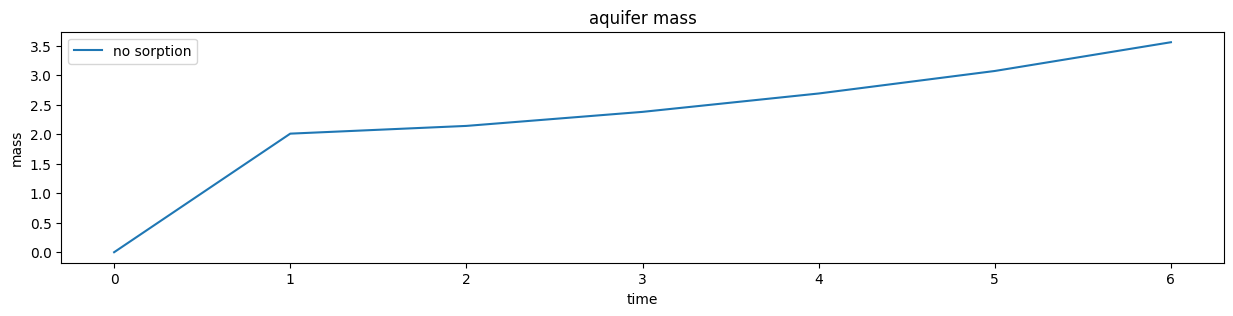

In [88]:
mass =[]
for i in range(0,c_out.shape[0]):
     mass.append(np.sum (c_out[i,:,:,:]*wc_out[i,:,:,:]))
# mass2 =[]
# for i in range(0,c_out2.shape[0]):
#      mass2.append(np.sum (c_out2[i,:,:,:]*wc_out[i,:,:,:]))
# mass3 =[]
# for i in range(0,c_out3.shape[0]):
#      mass3.append(np.sum (c_out3[i,:,:,:]*wc_out[i,:,:,:]))
# mass4 =[]
# for i in range(0,c_out4.shape[0]):
#      mass4.append(np.sum (c_out4[i,:,:,:]*wc_out[i,:,:,:]))
# mass5 =[]
# for i in range(0,c_out5.shape[0]):
#      mass5.append(np.sum (c_out5[i,:,:,:]*wc_out[i,:,:,:]))
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(mass[:],label='no sorption')
# plt.plot(mass2[:],label='linearly sorption',linestyle='--')
# plt.plot(mass3[:],label='no sorption-2')
# plt.plot(mass4[:],label='linearly sorption-2') 
# plt.plot(mass5[:],label='out-777-wc-gs')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('aquifer mass')
plt.legend()
plt.xlabel('time')
plt.ylabel('mass')
plt.show()

固相质量守恒

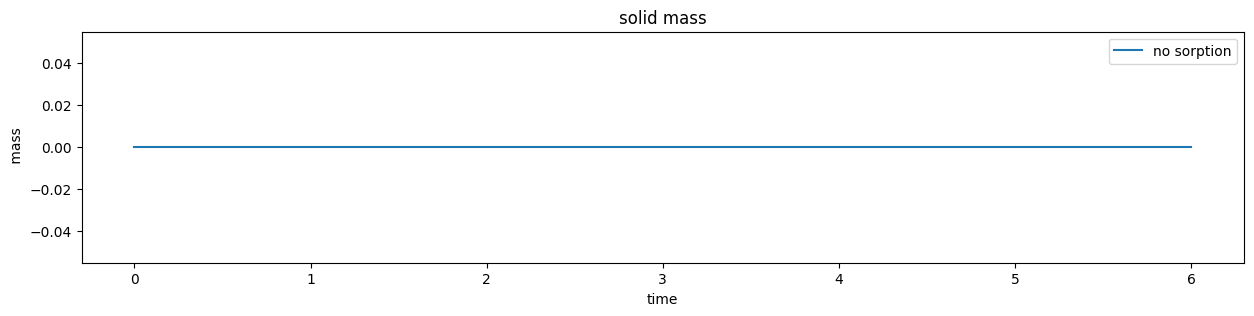

In [89]:
mass =[]
for i in range(0,cs_out.shape[0]):
     mass.append(np.sum (cs_out[i,:,:,:]))
# mass2 =[]
# for i in range(0,cs_out2.shape[0]):
#      mass2.append(np.sum (cs_out2[i,:,:,:]))
# mass3 =[]
# for i in range(0,c_out3.shape[0]):
#      mass3.append(np.sum (c_out3[i,:,:,:]*wc_out[i,:,:,:]))
# mass4 =[]
# for i in range(0,c_out4.shape[0]):
#      mass4.append(np.sum (c_out4[i,:,:,:]*wc_out[i,:,:,:]))
# mass5 =[]
# for i in range(0,c_out5.shape[0]):
#      mass5.append(np.sum (c_out5[i,:,:,:]*wc_out[i,:,:,:]))
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(mass[:],label='no sorption')
# plt.plot(mass2[:],label='linearly sorption',linestyle='--')
# plt.plot(mass3[:],label='no sorption-2')
# plt.plot(mass4[:],label='linearly sorption-2') 
# plt.plot(mass5[:],label='out-777-wc-gs')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('solid mass')
plt.legend()
plt.xlabel('time')
plt.ylabel(' mass')
plt.show()

水相+固相

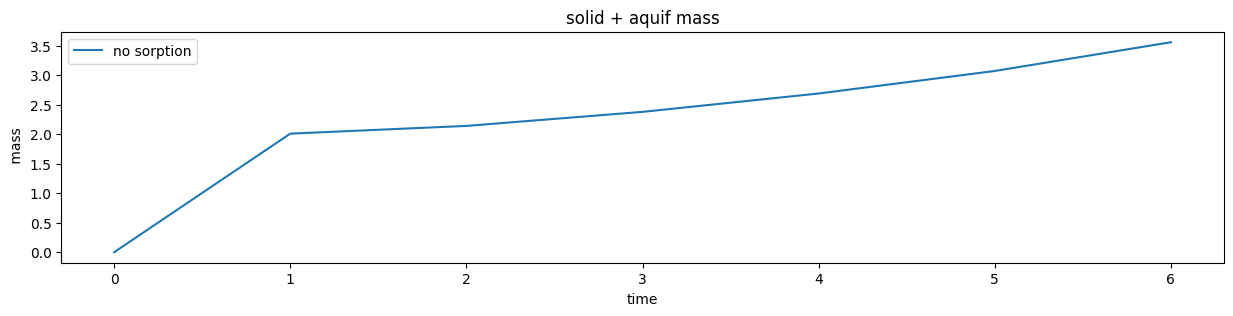

In [90]:
mass =[]
for i in range(0,cs_out.shape[0]):
     mass.append(np.sum (c_out[i,:,:,:]*wc_out[i,:,:,:]+cs_out[i,:,:,:]))
# mass2 =[]
# for i in range(0,cs_out2.shape[0]):
#      mass2.append(np.sum (c_out2[i,:,:,:]*wc_out[i,:,:,:]+cs_out2[i,:,:,:]))
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(mass[:],label='no sorption')
# plt.plot(mass2[:],label='linearly sorption',linestyle='--')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('solid + aquif mass')
plt.legend()
plt.xlabel('time')
plt.ylabel(' mass')
plt.show()

In [91]:
mass[c_out.shape[0]-1]

np.float64(3.559159881582975)

In [77]:
t=c_out.shape[0]-1
# t=1

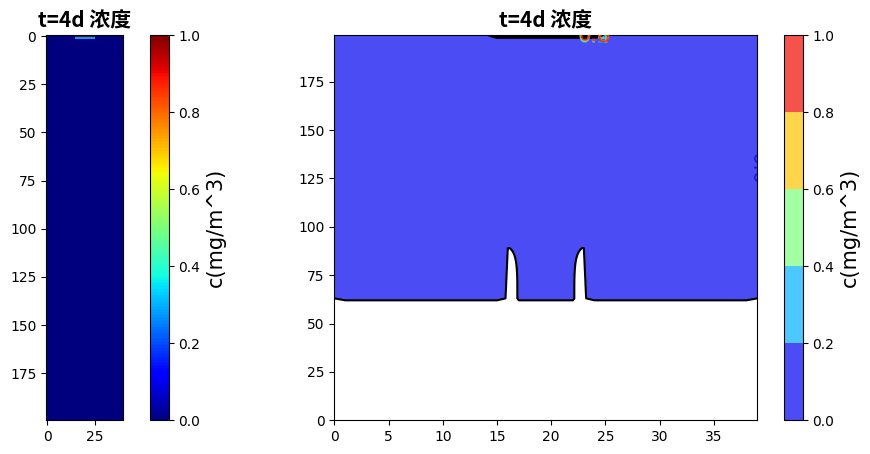

In [78]:
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.imshow((
                    c_out[t,:,0,:])
                  #   , extent=[0, 10, 0,5 ]
                    ,interpolation="nearest"   
                    ,cmap='jet'  
                    #  ,aspect=10 
                    #  , vmin=0.1
                    #  , vmax=1
                    )
          # plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}d 浓度".format(t), fontproperties=zhfont1,fontsize=15)
          # plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('c(mg/m^3)',fontsize=15)
plt.subplot(1, 2, 2)
contour = plt.contourf(
                         np.flipud(c_out[t,:,0,:])
                            , cmap='jet'
                           #  , extent=[0, 10, 0,5 ]
                            # , levels=np.linspace(np.min(c_out[t, :, 0, :]))
                         # , np.max(c_out[t, :, 0, :]), 100)
                         ,levels=[0,0.2,0.4,0.6,0.8,1]
                         ,alpha=0.7
                         
                         )
plt.contour(np.flipud(c_out[t,:,0,:]), levels=contour.levels, colors='k')
plt.clabel(contour, inline=True, fontsize=15)

plt.title("t={}d 浓度".format(t), fontproperties=zhfont1, fontsize=15)

     # 添加颜色条
cbar = plt.colorbar(contour)
cbar.ax.tick_params(labelsize=10)
cbar.set_label('c(mg/m^3)', fontsize=15)
# # 调整颜色条的大小
# # cbar.ax.set_aspect(10)
#   # 设置颜色条的长宽比，这里将长度设置为宽度的16倍
#     cbar.ax.set_position([0.8, 0.2, 0.2, 0.6])
# 代表colorbar的左边界、下边界、宽度、高度
plt.show()
# plt.savefig('images/4-11.png')

In [79]:
t=c_out.shape[0]-1
# t=1

In [80]:
index = np.where(c_out[t,:,0,:]<0)
c_out[t,:,0,:][index]=0

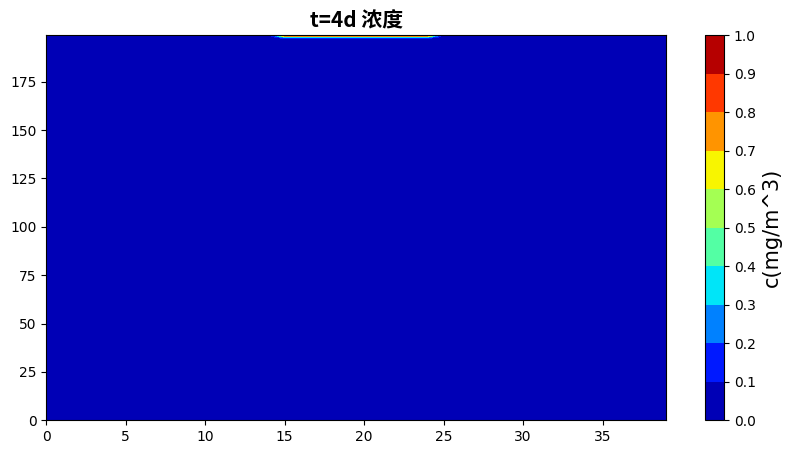

In [81]:
plt.figure(figsize=(10,5))
index = np.where(c_out[t,:,0,:]<0)
c_out[t,:,0,:][index]=0
contour = plt.contourf(
                         np.flipud(c_out[t,:,0,:])
                            , cmap='jet'
                           #  , extent=[0, 10, 0,5 ]
                            # , levels=np.linspace(np.min(c_out[t, :, 0, :]))
                         # , np.max(c_out[t, :, 0, :]), 100)
                         ,levels=np.arange(0, 1.1, 0.1) # 从0到1，间隔为0.1
                         ,alpha=1
                         
                         )
# plt.contour(np.flipud(c_out[t,:,0,:]), levels=contour.levels, colors='k')
# plt.clabel(contour, inline=True, fontsize=15)

plt.title("t={}d 浓度".format(t), fontproperties=zhfont1, fontsize=15)
# plt.title(" Developed model", fontsize=15)
# 添加颜色条
cbar = plt.colorbar(contour)
cbar.ax.tick_params(labelsize=10)
cbar.set_label('c(mg/m^3)', fontsize=15)

# 设置colorbar的ticks为0.1的间隔
cbar.set_ticks(np.arange(0, 1.1, 0.1))

plt.show()

In [82]:
# 时间序列文件输出
data_to_save = np.column_stack((t_out[:], c_out[:,16,0,20]))
np.savetxt('c_out-timeseries.txt',data_to_save,delimiter=' ',fmt='%.3f' )

diff and dcal plot

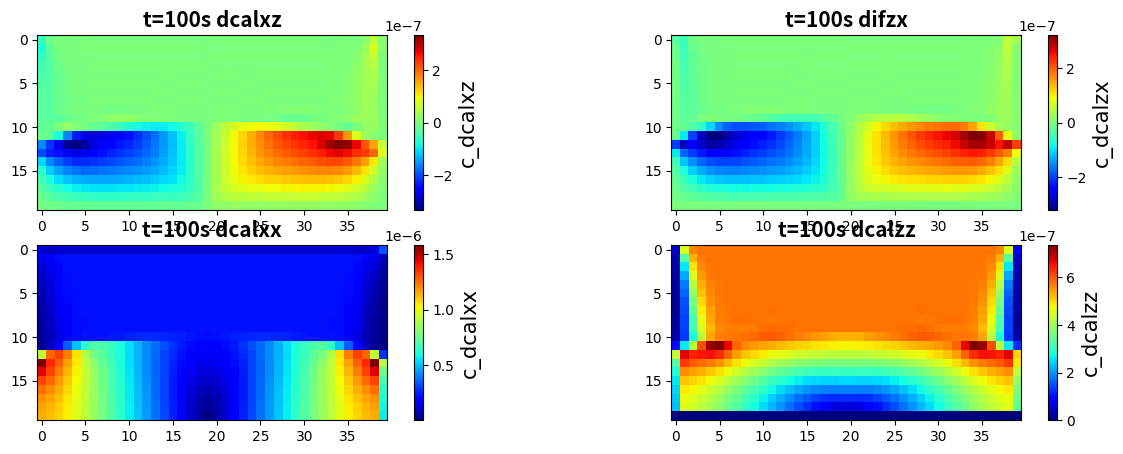

In [116]:
plt.figure(figsize=(15,5))
plt.subplot(2, 2, 1)
plt.imshow((
                    c_difxz_out[t,:,0,:])
                  #   , extent=[0, 10, 0,5 ]
                    ,interpolation="nearest"   
                    ,cmap='jet'  
                    #  ,aspect=10 
                    #  , vmin=0.1
                    #  , vmax=1
                    )
          # plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}s dcalxz".format(t), fontproperties=zhfont1,fontsize=15)
          # plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('c_dcalxz',fontsize=15)
plt.subplot(2, 2, 2)
plt.imshow((
                    c_difzx_out[t,:,0,:])
                  #   , extent=[0, 10, 0,5 ]
                    ,interpolation="nearest"   
                    ,cmap='jet'  
                    #  ,aspect=10 
                    #  , vmin=0.1
                    #  , vmax=1
                    )
          # plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}s difzx".format(t), fontproperties=zhfont1,fontsize=15)
          # plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('c_dcalzx',fontsize=15)
plt.subplot(2, 2, 3)
plt.imshow((
                    c_difxx_out[t,:,0,:])
                  #   , extent=[0, 10, 0,5 ]
                    ,interpolation="nearest"   
                    ,cmap='jet'  
                    #  ,aspect=10 
                    #  , vmin=0.1
                    #  , vmax=1
                    )
          # plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}s dcalxx".format(t), fontproperties=zhfont1,fontsize=15)
          # plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('c_dcalxx',fontsize=15)
plt.subplot(2, 2, 4)
plt.imshow((
                    c_difzz_out[t,:,0,:])
                  #   , extent=[0, 10, 0,5 ]
                    ,interpolation="nearest"   
                    ,cmap='jet'  
                    #  ,aspect=10 
                    #  , vmin=0.1
                    #  , vmax=1
                    )
          # plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}s dcalzz".format(t), fontproperties=zhfont1,fontsize=15)
          # plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('c_dcalzz',fontsize=15)

不同求解方法结果对比

In [117]:
t = wc_out.shape[0]-1
# t = 0

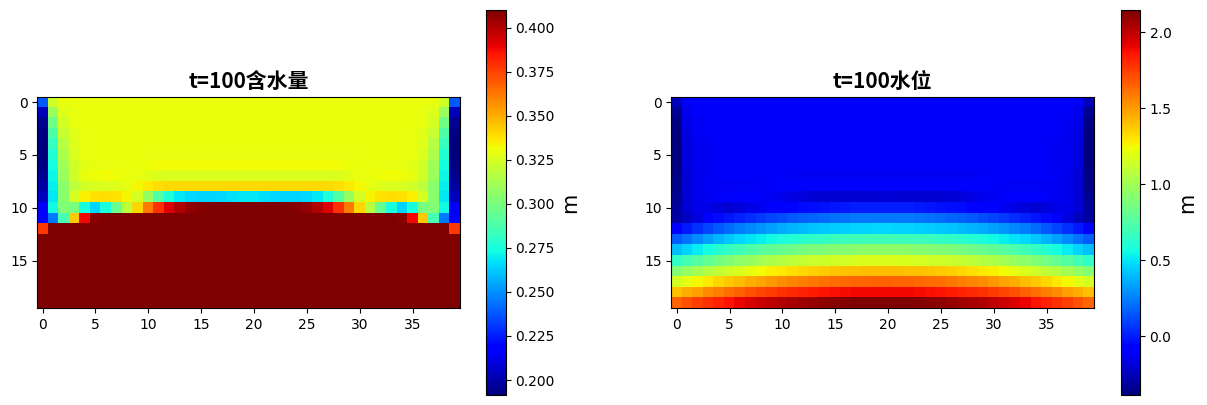

In [118]:
plt.figure(figsize=[15,5],dpi=100)
plt.subplot(1, 2, 1)
plt.imshow((wc_out[t,:,0,:])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
        #    ,aspect=0.01 
          # , vmin=-0.00002#  , vmax=0.00002
           )
# plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}含水量".format(t), fontproperties=zhfont1,fontsize=15)
# plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m',fontsize=15)
plt.subplot(1, 2, 2)
plt.imshow((h_out[t,:,0,:])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
        #   ,aspect=0.01
          #, vmin=-0.00002#  
          # , vmax=0.00002
           )
# plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}水位".format(t), fontproperties=zhfont1,fontsize=15)
# plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m',fontsize=15)
# # 调整颜色条的大小
# # cbar.ax.set_aspect(10)
#   # 设置颜色条的长宽比，这里将长度设置为宽度的16倍
#     cbar.ax.set_position([0.8, 0.2, 0.2, 0.6])
# 代表colorbar的左边界、下边界、宽度、高度
# plt.savefig('images/4-11.png')
plt.show()
# plt.savefig('images/4-11.png')

In [119]:
wc_out[t,:,0,20]

masked_array(data=[0.33008226, 0.33004656, 0.33013072, 0.32993192,
                   0.33039955, 0.32928807, 0.3318678 , 0.32550959,
                   0.33934222, 0.26833226, 0.41      , 0.41      ,
                   0.41      , 0.41      , 0.41      , 0.41      ,
                   0.41      , 0.41      , 0.41      , 0.41      ],
             mask=False,
       fill_value=1e+20)

地下水水位

地下水流速

In [120]:
t=qz_out.shape[0]-1
# t = 1

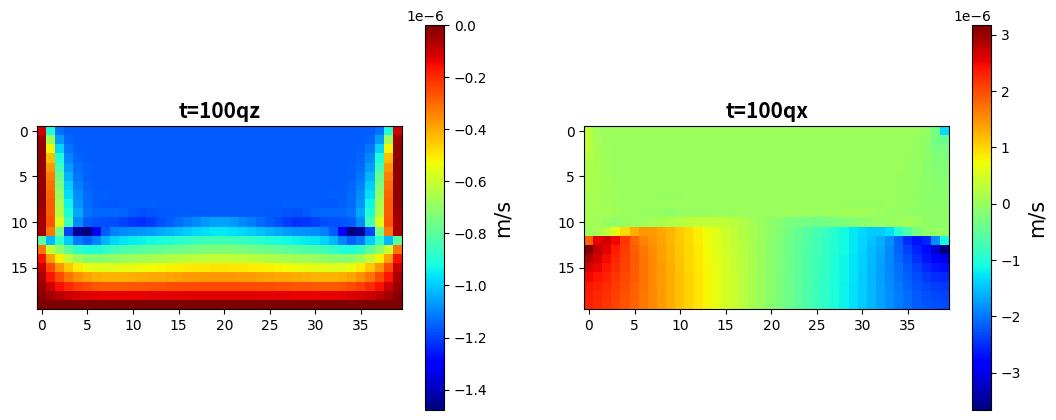

In [121]:
plt.figure(figsize=[20,5],dpi=100)
plt.subplot(1, 3, 1)
plt.imshow((qz_out[t,:,0,:])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
          #  ,aspect=30#
        #   , vmin=0  
          # , vmax=0
           )
# plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}qz".format(t), fontproperties=zhfont1,fontsize=15)
# plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m/s',fontsize=15)
plt.subplot(1, 3, 2)
plt.imshow((qx_out[t,:,0,:])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
          #  ,aspect=30#  
        #   , vmin=-1e-5 
        #   , vmax= 1e-5 
           )
plt.title("t={}qx".format(t), fontproperties=zhfont1,fontsize=15)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m/s',fontsize=15)
# # 调整颜色条的大小
# # cbar.ax.set_aspect(10)
#   # 设置颜色条的长宽比，这里将长度设置为宽度的16倍
#     cbar.ax.set_position([0.8, 0.2, 0.2, 0.6])
# 代表colorbar的左边界、下边界、宽度、高度
plt.show()
# plt.savefig('images/4-11.png')

In [134]:
t=8

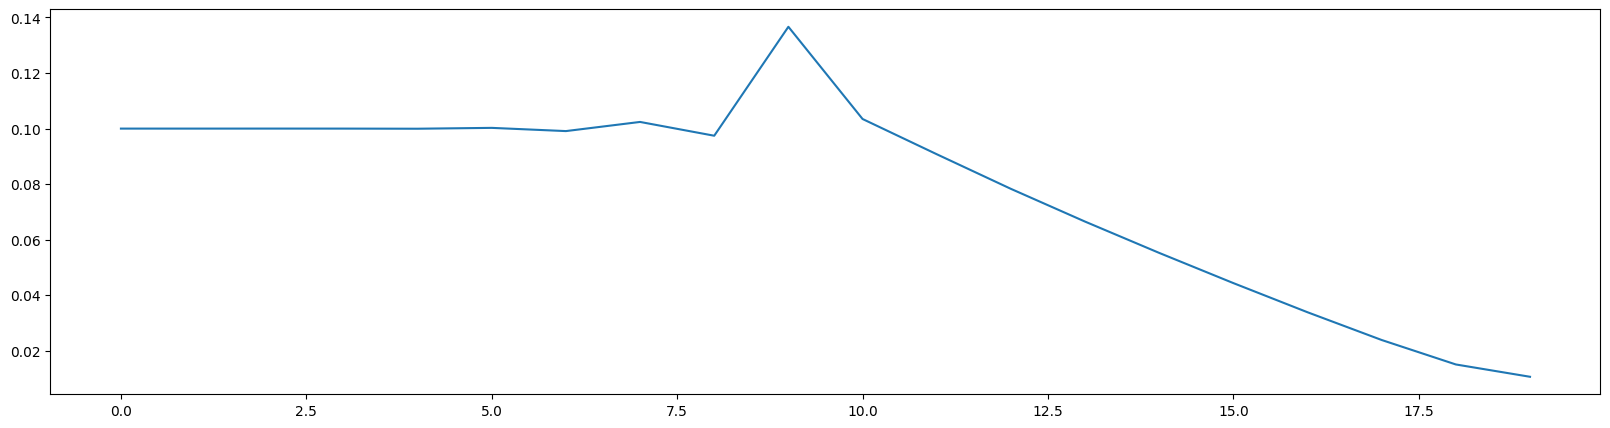

In [135]:
plt.figure(figsize=[20,5],dpi=100)
data = np.pow(np.pow(qz_out[t,:,0,20]*-86400,2)+np.pow(qx_out[t,:,0,20]*-86400,2),0.5)
plt.plot(data)
plt.show()

In [136]:
# 剖面流速输出
data_to_save = np.column_stack((z_out[:,0,20], data))
np.savetxt('c_out-poumian.txt',data_to_save,delimiter=' ',fmt='%.3f' )

In [137]:
np.where(qz_out[t,:,0,:]>0)

(array([10, 10, 11, 11, 11, 11]), array([ 0, 39,  0,  1, 38, 39]))

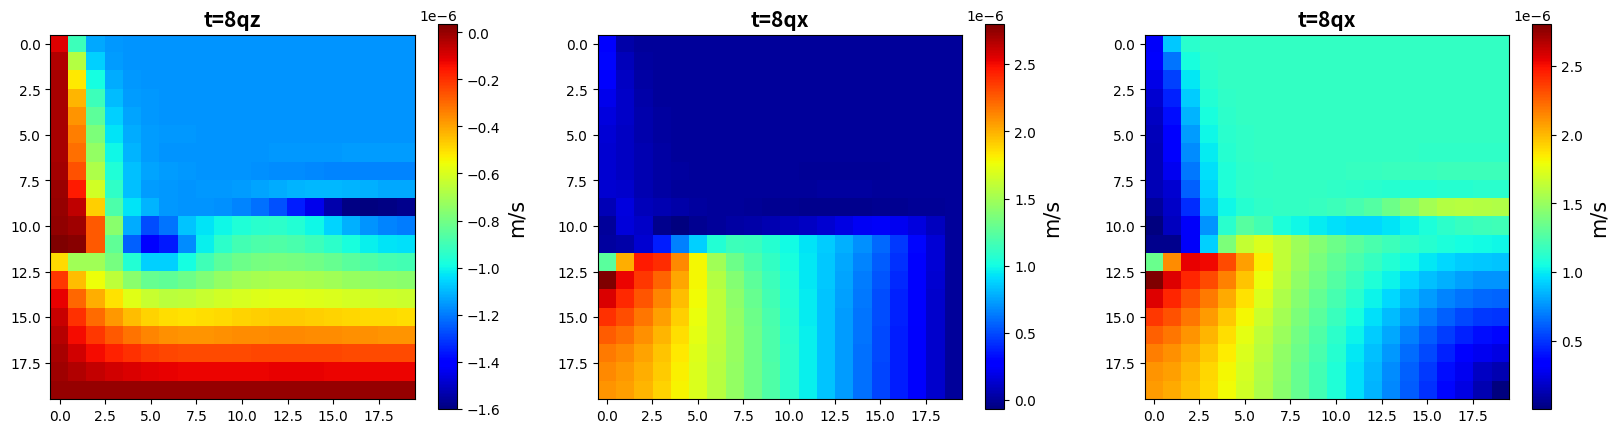

In [138]:
plt.figure(figsize=[20,5],dpi=100)
plt.subplot(1, 3, 1)
plt.imshow((qz_out[t,:,0,0:20])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
          #  ,aspect=30#  , vmin=-0.00002#  , vmax=0.00002
           )
# plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}qz".format(t), fontproperties=zhfont1,fontsize=15)
# plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m/s',fontsize=15)
plt.subplot(1, 3, 2)
plt.imshow((qx_out[t,:,0,0:20])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
          #  ,aspect=30#  
        #   , vmin=-1e-5 
        #   , vmax= 1e-5 
           )
plt.title("t={}qx".format(t), fontproperties=zhfont1,fontsize=15)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m/s',fontsize=15)
plt.subplot(1, 3, 3) 
plt.imshow((np.sqrt(pow(qx_out[t,:,0,0:20],2)+pow(qz_out[t,:,0,0:20],2)))
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
          #  ,aspect=30#  
        #   , vmin=-1e-5 
        #   , vmax= 1e-5 
           )
plt.title("t={}qx".format(t), fontproperties=zhfont1,fontsize=15)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m/s',fontsize=15)
plt.show()

In [139]:
qx_out[1,0,:,:]

masked_array(data=[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
                    0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
                    0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
                    0.]],
             mask=False,
       fill_value=1e+20)

IndexError: index 50 is out of bounds for axis 3 with size 40

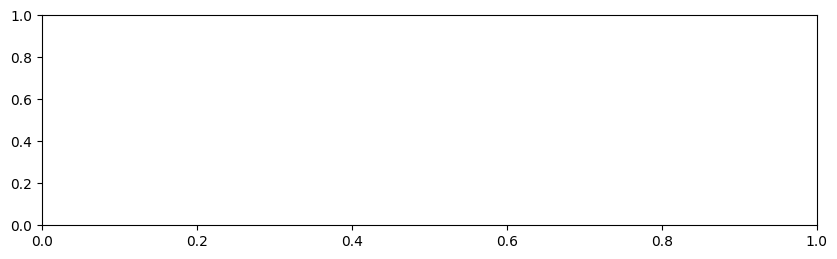

In [140]:
# 纵向浓度变化
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
# plt.plot(c_out[:,0,0,50],label='t=-1')   
plt.plot(qz_out[0,:,0,50],label='t=0',linestyle='--')
plt.plot(qz_out[1,:,0,50],label='t=-2',linestyle='--')
plt.plot(qz_out[-1,:,0,50],label='t=-1',linestyle='--')
plt.xlabel('z')
# plt.label('time')
plt.title('纵向浓度变化',fontproperties=zhfont1)
plt.legend(loc='upper right')
plt.show
